In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats

In [2]:
df = pd.read_csv('json_test.csv')

In [7]:
tests = [(pd.read_csv(filename)) for filename in ["TestSegments\Baseline1.csv", "TestSegments\Baseline2.csv", "TestSegments\Bump1.csv", "TestSegments\DoubleBump1.csv", "TestSegments\SmallLargeBump1.csv","TestSegments\SmallLargeBump2.csv"]]

for i in range(len(tests)):
    
    tests[i]['time'] = pd.to_datetime(tests[i]['time'])
    tests[i]['acc_z_norm'] = tests[i]['acc_z'] - 9.81 # difference from acceleration due to gravity
    tests[i]['acc_z_absn'] = abs(tests[i]['acc_z_norm'])
    tests[i]['acc_z_nroll'] = tests[i]['acc_z_norm'].rolling(5).sum() / 5

    tests[i]['acc_x_norm'] = tests[i]['acc_x'] - tests[i]['acc_x'].mean()
    tests[i]['acc_x_absn'] = abs(tests[i]['acc_x_norm'])
    tests[i]['acc_x_nroll'] = tests[i]['acc_x_norm'].rolling(5).sum() / 5


In [3]:
ROLLING_RANGE = 25

df['time'] = pd.to_datetime(df['time'])
df['acc_z_norm'] = df['acc_z'] - 9.81 # difference from acceleration due to gravity
df['acc_z_absn'] = abs(df['acc_z_norm'])
df['acc_z_nroll'] = df['acc_z_norm'].rolling(ROLLING_RANGE).mean()
df['acc_z_mag_nroll'] = df['acc_z_absn'].rolling(ROLLING_RANGE).mean()

df['acc_x_norm'] = df['acc_x'] - df['acc_x'].mean()
df['acc_x_absn'] = abs(df['acc_x_norm'])
df['acc_x_nroll'] = df['acc_x_norm'].rolling(ROLLING_RANGE).mean()
df['acc_x_mag_nroll'] = df['acc_x_absn'].rolling(ROLLING_RANGE).mean()

df['speed_roll'] = df['speed'].rolling(ROLLING_RANGE).mean()



In [4]:
df['acc_x'].mean()

-0.7152996666441955

In [ ]:
df['delta_time'] = 0
df['estimated_distance'] = 0
df['estimated_velocity'] = 0

for i in range(ROLLING_RANGE, len(df)):
    if i % 1000 == 0:
        print(f"{i} / {len(df)}")
    df.loc[i, 'delta_time'] = (df.loc[i, 'time'] - df.loc[i-1, 'time']).value / (10**9)
    df.loc[i, 'estimated_velocity'] = df.loc[i-1, 'estimated_velocity'] + (df.loc[i, 'acc_x_nroll'] * df.loc[i, 'delta_time'])
    df.loc[i, 'estimated_distance'] = df.loc[i-1, 'estimated_distance'] + (df.loc[i, 'estimated_velocity'] * df.loc[i, 'delta_time'])

In [4]:
df = df[df['speed'] > 1]

<Axes: xlabel='speed', ylabel='Count'>

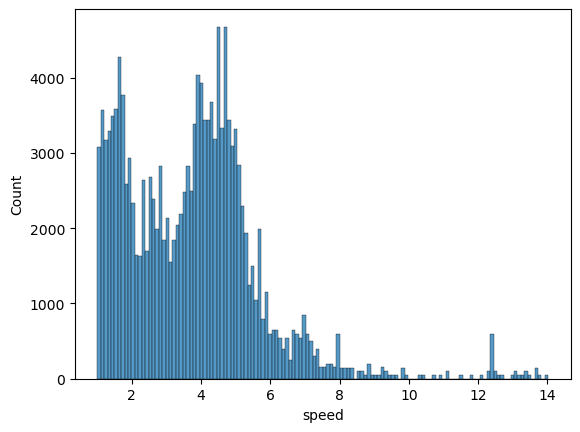

In [114]:
sns.histplot(df['speed'])

In [88]:
df['speed'].describe()

count    162335.000000
mean          3.516020
std           2.045067
min           0.751000
25%           1.751000
50%           3.553000
75%           4.698000
max          14.022000
Name: speed, dtype: float64

In [8]:
df['estimated_velocity_abs'] = df['estimated_velocity'].abs()

<Axes: xlabel='time', ylabel='speed_roll'>

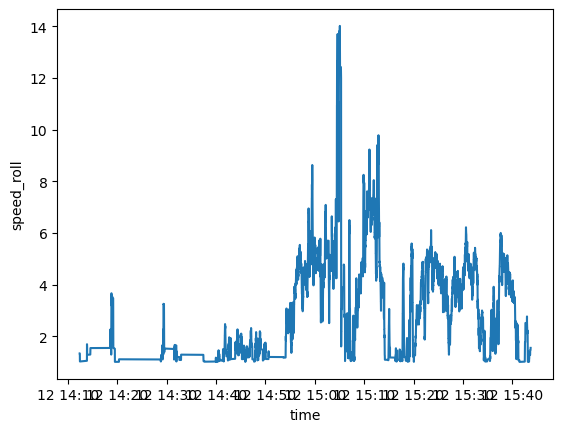

In [111]:
sns.lineplot(data=df, x='time', y='speed_roll')

In [9]:
df[['acc_x_norm', 'acc_z_norm', 'acc_x_absn', 'acc_z_absn',  'acc_x_mag_nroll', 'acc_z_mag_nroll', 'speed', 'speed_roll']].corr()

,acc_x_norm,acc_z_norm,acc_x_absn,acc_z_absn,acc_x_mag_nroll,acc_z_mag_nroll,speed,speed_roll
acc_x_norm,1.000000,-0.091969,-0.077421,-0.036433,-0.004540,0.004737,0.010342,0.010436
acc_z_norm,-0.091969,1.000000,0.227053,0.446094,0.013098,0.029505,-0.001452,-0.001444
acc_x_absn,-0.077421,0.227053,1.000000,0.297181,0.478245,0.364294,0.209662,0.208764
acc_z_absn,-0.036433,0.446094,0.297181,1.000000,0.394995,0.497794,0.260224,0.259452
acc_x_mag_nroll,-0.004540,0.013098,0.478245,0.394995,1.000000,0.769849,0.437949,0.436660
acc_z_mag_nroll,0.004737,0.029505,0.364294,0.497794,0.769849,1.000000,0.513846,0.512527
speed,0.010342,-0.001452,0.209662,0.260224,0.437949,0.513846,1.000000,0.997275
speed_roll,0.010436,-0.001444,0.208764,0.259452,0.436660,0.512527,0.997275,1.000000


c:\Users\bodes\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


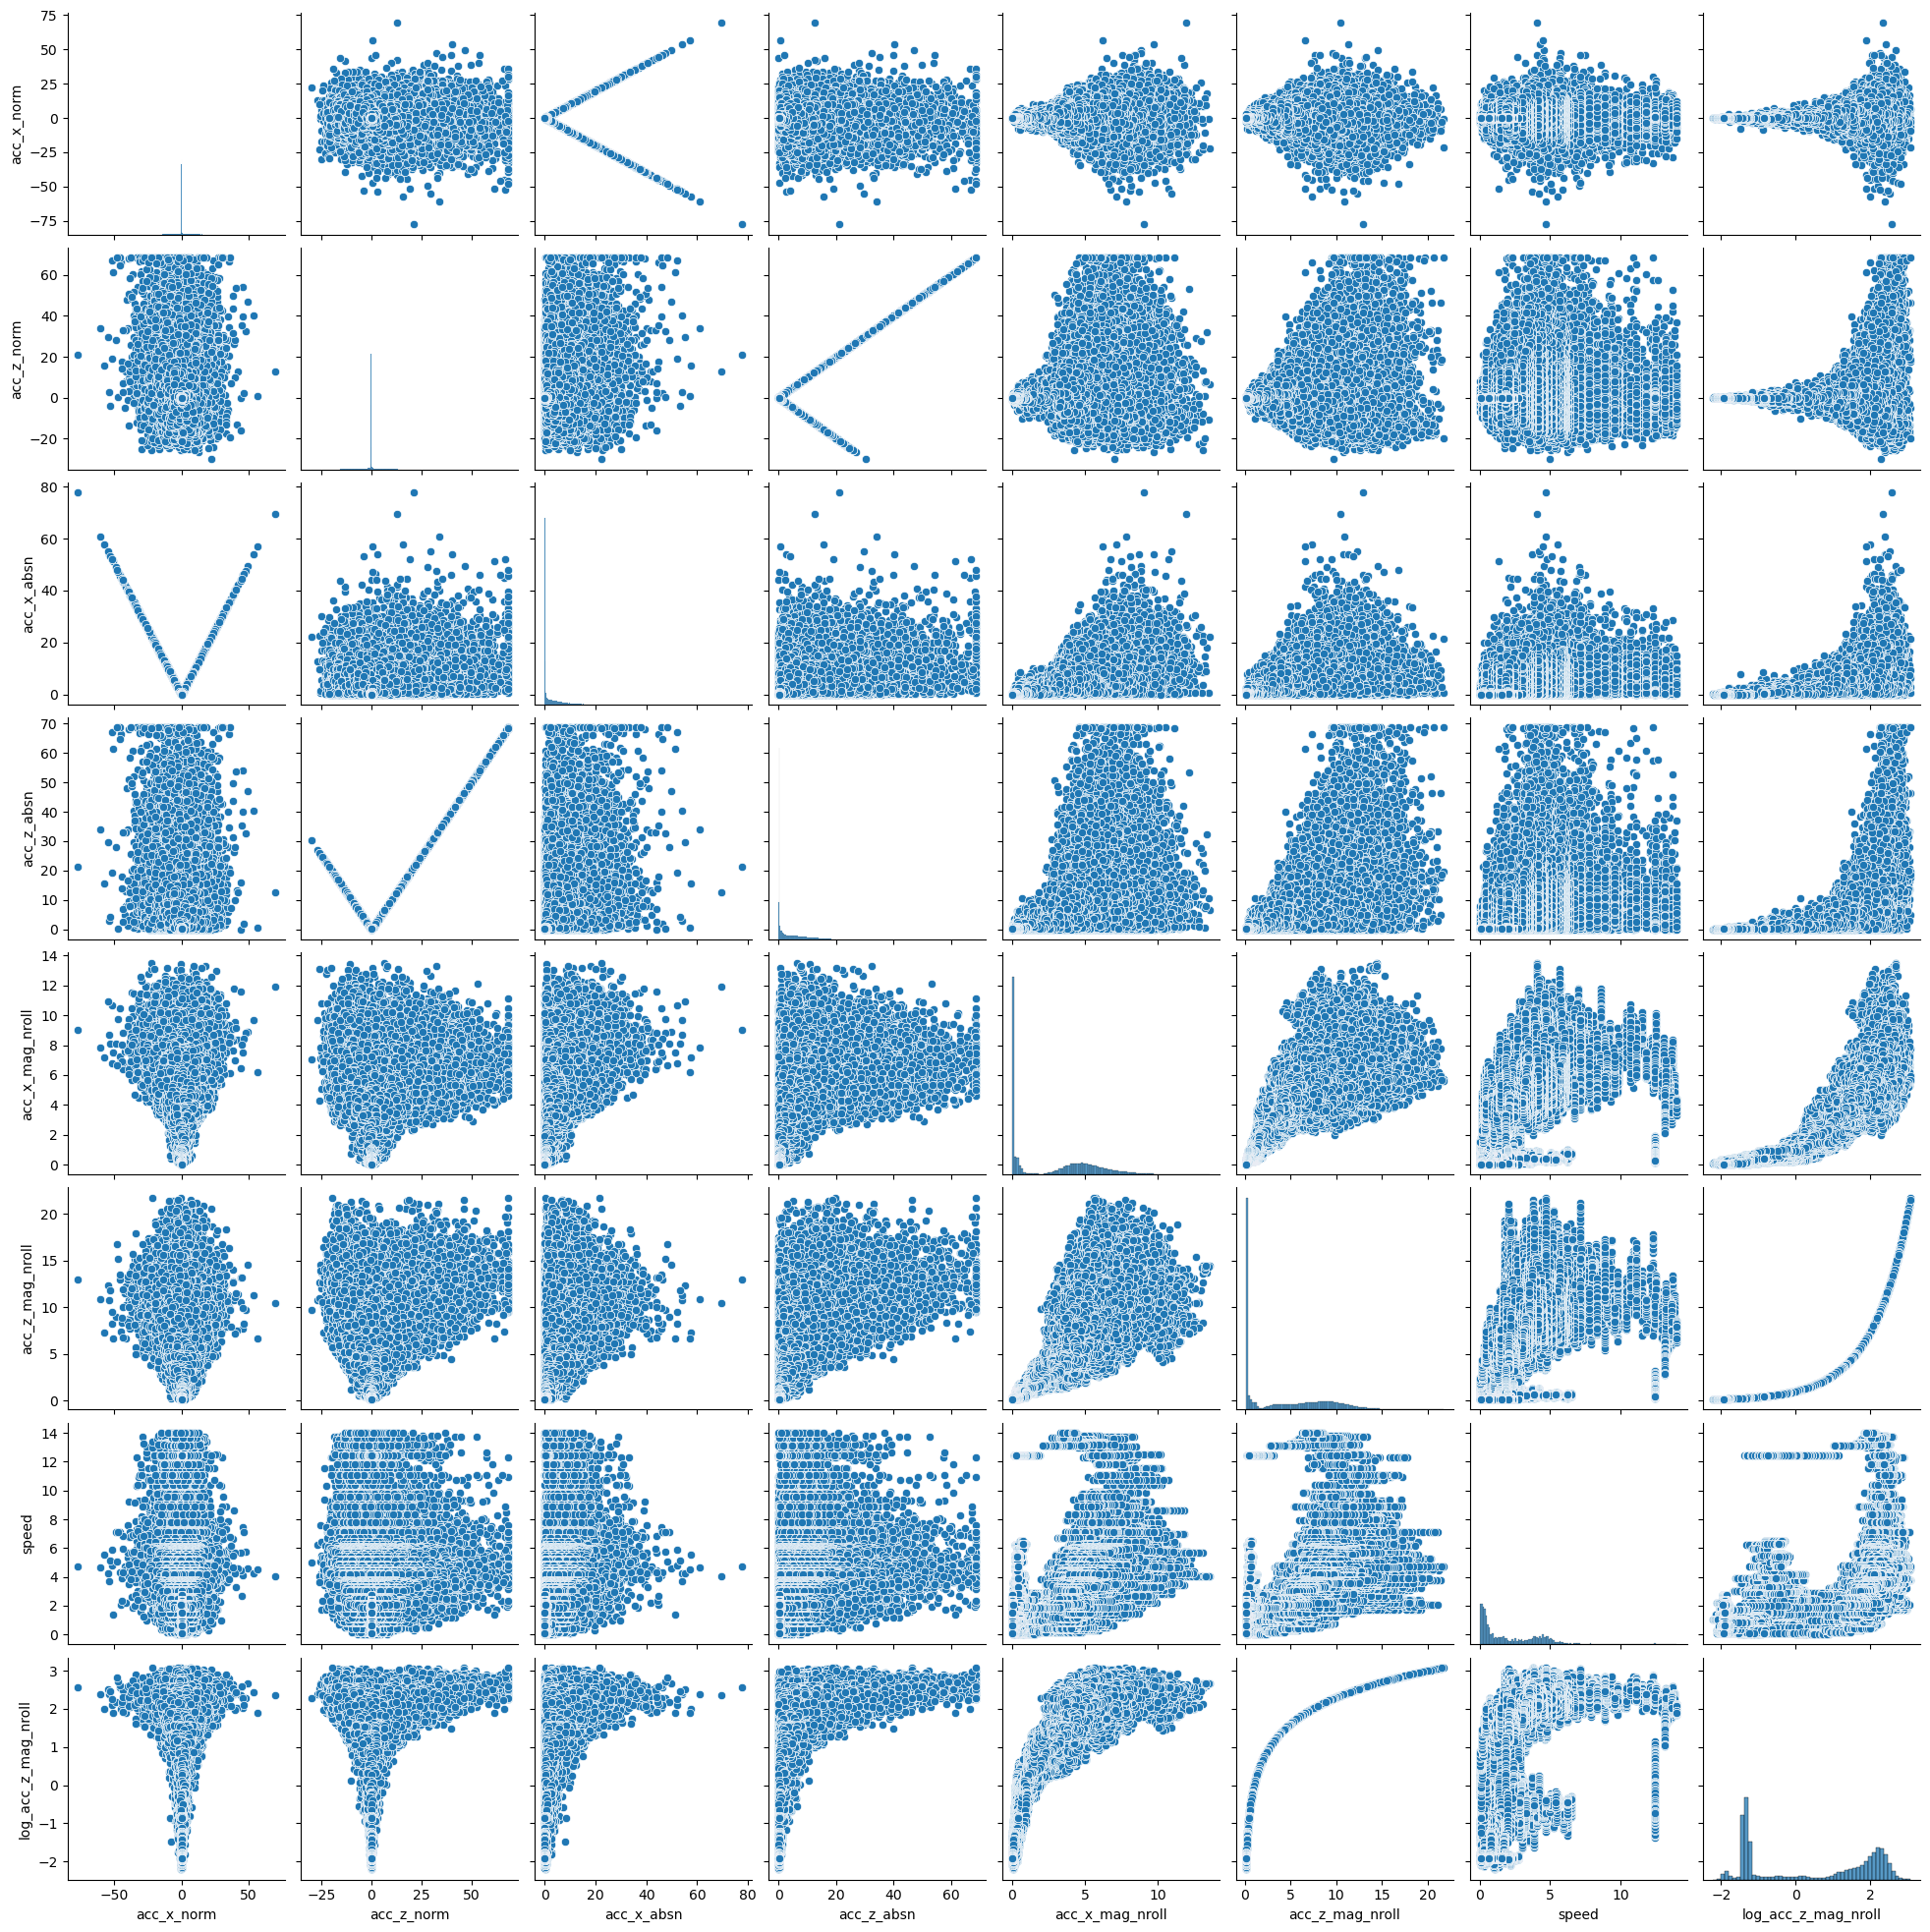

In [ ]:
sns.pairplot(data=df[['acc_x_norm', 'acc_z_norm', 'acc_x_absn', 'acc_z_absn',  'acc_x_mag_nroll', 'acc_z_mag_nroll', 'speed']])

<Axes: xlabel='time', ylabel='speed'>

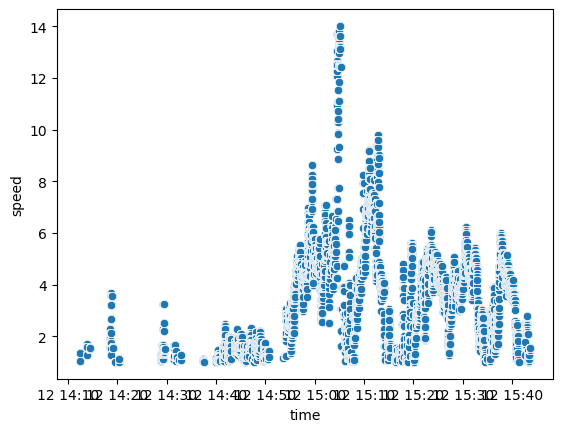

In [109]:
sns.scatterplot(data=df, x='time', y='speed')

In [56]:
df['delta_time'].describe()

count    240684.000000
mean          0.020116
std           0.000314
min           0.000000
25%           0.020090
50%           0.020108
75%           0.020137
max           0.027936
Name: delta_time, dtype: float64

In [120]:
df = df.dropna()

In [125]:
np.ones(len(df['speed']))

array([1., 1., 1., ..., 1., 1., 1.])

In [22]:
speed_model =  sm.OLS(df['acc_z_mag_nroll'], sm.add_constant(np.array(df[['speed']]))).fit()
speed_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        acc_z_mag_nroll   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                 5.309e+04
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:20:07   Log-Likelihood:            -3.8358e+05
No. Observations:              148698   AIC:                         7.672e+05
Df Residuals:                  148696   BIC:                         7.672e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7252      0.018    208.538      0.000       3.690       3.760
x1             0.9703      0.004    230.410      0.000       0.962       0.979
==============================================================================
Omnibus:                    14913.181   Durbin-Watson:                   0.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            38454.491
Skew:                          -0.582   Prob(JB):                         0.00
Kurtosis:                       5.202   Cond. No.                         9.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
mlr_model = sm.OLS(df['acc_z_mag_nroll'], sm.add_constant(np.array(df[['speed', 'acc_x_mag_nroll']]))).fit()
mlr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        acc_z_mag_nroll   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                 1.270e+05
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:49:57   Log-Likelihood:            -3.3220e+05
No. Observations:              148698   AIC:                         6.644e+05
Df Residuals:                  148695   BIC:                         6.644e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3895      0.015     25.409      0.000       0.359       0.420
x1             0.4122      0.003    124.335      0.000       0.406       0.419
x2             1.1214      0.003    384.794      0.000       1.116       1.127
==============================================================================
Omnibus:                     9521.272   Durbin-Watson:                   0.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14900.553
Skew:                           0.527   Prob(JB):                         0.00
Kurtosis:                       4.138   Cond. No.                         17.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
acc_model = sm.OLS(df['acc_z_mag_nroll'], sm.add_constant(np.array(df[['acc_x_mag_nroll']]))).fit()
acc_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        acc_z_mag_nroll   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                 2.161e+05
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:02   Log-Likelihood:            -3.3956e+05
No. Observations:              148698   AIC:                         6.791e+05
Df Residuals:                  148696   BIC:                         6.791e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1707      0.015     79.677      0.000       1.142       1.200
x1             1.2800      0.003    464.861      0.000       1.275       1.285
==============================================================================
Omnibus:                     7465.791   Durbin-Watson:                   0.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9714.993
Skew:                           0.501   Prob(JB):                         0.00
Kurtosis:                       3.751   Cond. No.                         13.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
df['acc_z_pred'] = speed_model.predict()


In [50]:
df['e'] = df['acc_z_mag_nroll'] - df['acc_z_pred']

In [48]:
df[df['e'] > 11]['e'].describe()

count    141.000000
mean      12.519940
std        1.096922
min       11.009070
25%       11.579226
50%       12.313700
75%       13.264035
max       15.364540
Name: e, dtype: float64

<Axes: xlabel='e', ylabel='Count'>

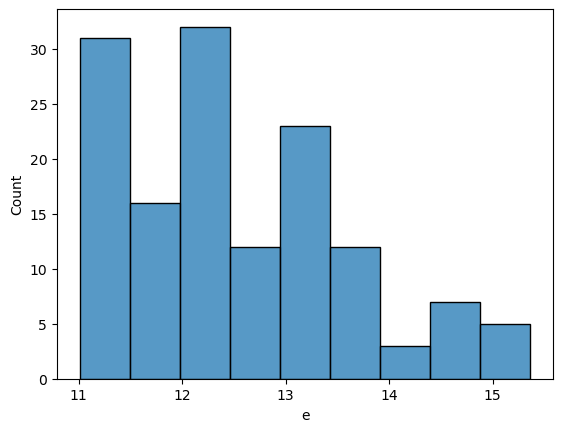

In [47]:
sns.histplot(data=df[df['e'] > 11]['e'])

In [27]:
n = len(df['e']-2)
mse = np.sum(df['e']**2) / n
x_mean = df['speed'].mean()
xi_xbar = ((df['speed'] - x_mean)**2).sum()

def prediction_range(xh, alpha):

    return stats.t.ppf(1-alpha/2,n) * (mse * (1 + (1/n) + ((xh-x_mean)**2 / xi_xbar)))**0.5

In [33]:
df['range'] = prediction_range(df['speed'], 0.001)
df['outlier'] = abs(df['e']) > df['range']

<Axes: xlabel='speed', ylabel='range'>

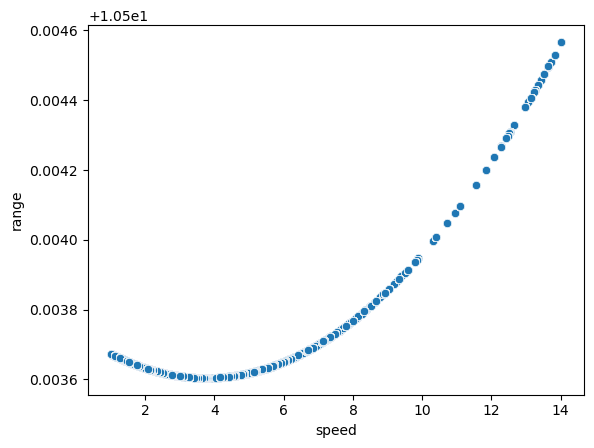

In [44]:
sns.scatterplot(data=df, x=df['speed'], y=df['range'])

In [14]:
df['e'].describe()

count    1.486980e+05
mean     4.972624e-15
std      2.259480e+00
min     -1.003740e+01
25%     -1.404111e+00
50%     -3.253273e-01
75%      1.311023e+00
max      1.391449e+01
Name: e, dtype: float64

In [24]:
df['range'].describe()

count    148698.000000
mean          4.653067
std           0.000024
min           4.653051
25%           4.653052
50%           4.653055
75%           4.653069
max           4.653287
Name: range, dtype: float64

In [25]:
filtered_df = df[abs(df['e']) < 1]

In [18]:
df['outlier'].describe()

count     148698
unique         2
top        False
freq      148481
Name: outlier, dtype: object

<Axes: xlabel='acc_z_pred', ylabel='acc_z_mag_nroll'>

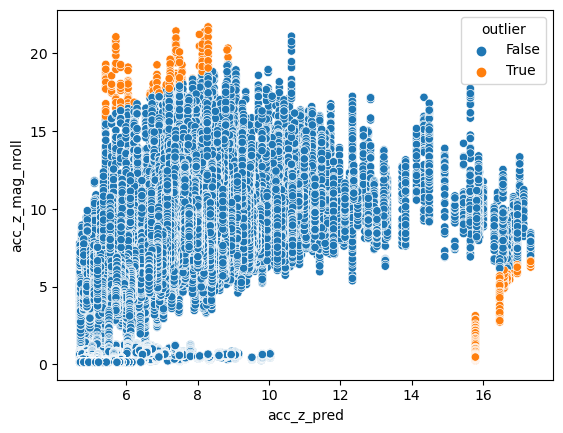

In [45]:
sns.scatterplot(data=df, x='acc_z_pred', y='acc_z_mag_nroll', hue='outlier')

In [16]:
def remove_repeated_detection(array, recency_threshold):
    new_array = array.copy()
    iterations_since_poi = recency_threshold
    for i in range(len(new_array)):
        iterations_since_poi += 1
        if new_array.iloc[i] == True:
            if iterations_since_poi < recency_threshold:
                new_array.iloc[i] = False
            iterations_since_poi = 0
    return new_array

In [46]:
df['outlier'] = remove_repeated_detection(df['outlier'], 40)

<Axes: xlabel='e', ylabel='Count'>

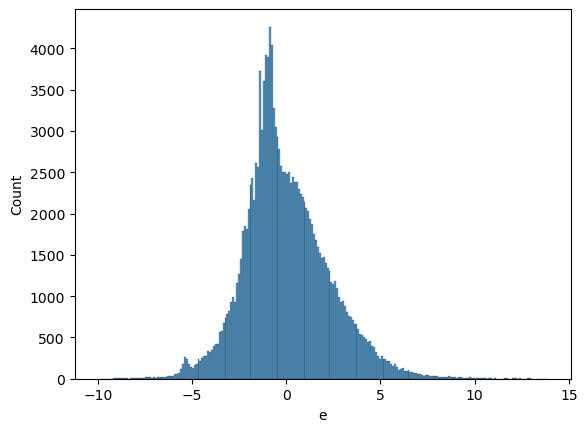

In [138]:
sns.histplot(df['e'])

<Axes: xlabel='time', ylabel='acc_z_pred'>

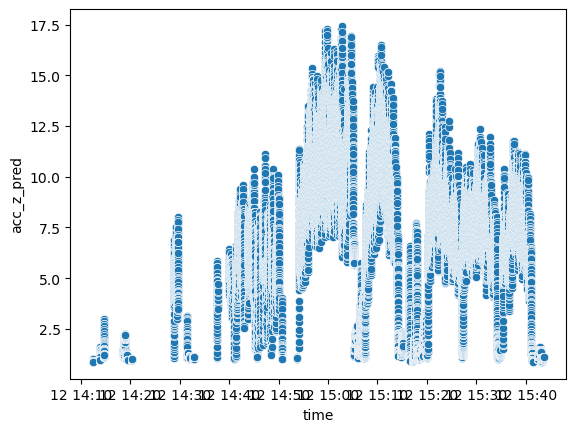

In [139]:
sns.scatterplot(data=df, x='time', y='acc_z_pred')

<Axes: xlabel='time', ylabel='acc_z_mag_nroll'>

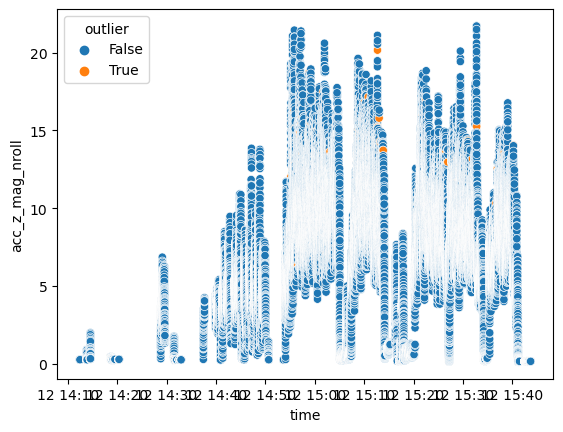

In [148]:
sns.scatterplot(data=df, x='time', y='acc_z_mag_nroll', hue='outlier')

<Axes: xlabel='time', ylabel='acc_z_mag_nroll'>

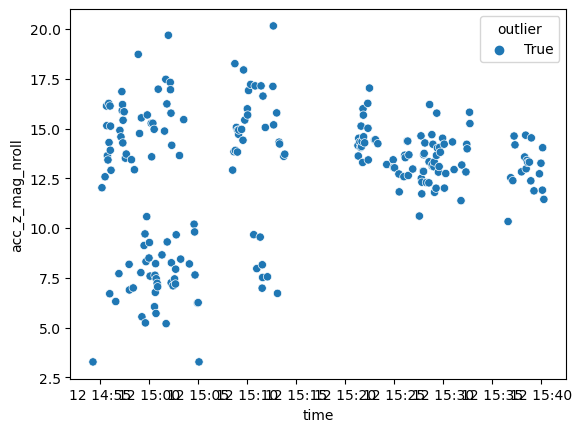

In [149]:
sns.scatterplot(data=df[df['outlier'] == True], x='time', y='acc_z_mag_nroll', hue='outlier')

In [142]:
df[df['outlier'] == True]

,Unnamed: 0,class,device,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,...,acc_x_mag_nroll,delta_time,estimated_distance,estimated_velocity,estimated_velocity_abs,acc_z_pred,e,log_acc_z_mag_nroll,outlier,range
132330,132330,ATT,LSM9DS1,2025-10-12 14:55:09.821398+00:00,-2.024328,-0.775275,-9.358329,99.40,-11.06,-27.86,...,5.205078,0.020105,-329060.875880,-265.325020,265.325020,7.833139,8.306056,2.781251,True,7.811965
132331,132331,ATT,LSM9DS1,2025-10-12 14:55:09.841413+00:00,6.218946,8.549555,2.179861,-86.31,37.80,58.87,...,5.114521,0.020015,-329066.186205,-265.317280,265.317280,7.717227,8.640001,2.794670,True,7.811965
132334,132334,ATT,LSM9DS1,2025-10-12 14:55:09.901681+00:00,25.170101,-22.537996,67.941805,-104.51,87.22,-2.80,...,6.401081,0.020107,-329082.175158,-265.282640,265.282640,9.364009,8.384694,2.876312,True,7.811977
132335,132335,ATT,LSM9DS1,2025-10-12 14:55:09.921812+00:00,2.167897,5.106283,-3.129812,6.23,-28.70,3.99,...,6.427498,0.020131,-329087.515132,-265.261268,265.261268,9.397822,8.450855,2.881929,True,7.811978
132336,132336,ATT,LSM9DS1,2025-10-12 14:55:09.941863+00:00,-3.160919,-5.613562,-2.701497,-21.00,-21.91,20.58,...,6.467806,0.020051,-329092.833522,-265.243095,265.243095,9.449416,8.267369,2.874512,True,7.811978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262746,262746,ATT,LSM9DS1,2025-10-12 15:38:51.310797+00:00,-1.540978,-1.251446,-4.235296,2.17,-19.95,-7.77,...,4.419932,0.020085,-633380.532296,-8.206128,8.206128,6.828163,8.036511,2.698988,True,7.811965
262748,262748,ATT,LSM9DS1,2025-10-12 15:38:51.350988+00:00,-1.655833,-0.559920,0.849452,-13.51,-14.21,-1.26,...,4.228219,0.020041,-633380.861032,-8.175103,8.175103,6.582772,7.886270,2.672011,True,7.811966
262749,262749,ATT,LSM9DS1,2025-10-12 15:38:51.371081+00:00,0.976272,4.201796,16.713866,36.47,-8.47,8.89,...,3.966049,0.020093,-633381.024963,-8.158646,8.158646,6.247198,8.242564,2.673442,True,7.811968
263336,263336,ATT,LSM9DS1,2025-10-12 15:39:03.169741+00:00,3.168097,-4.630112,48.500121,-35.91,8.54,-0.28,...,5.506261,0.020035,-633432.609853,-1.514899,1.514899,8.218651,8.416758,2.811533,True,7.811967


<Axes: xlabel='acc_x_mag_nroll', ylabel='e'>

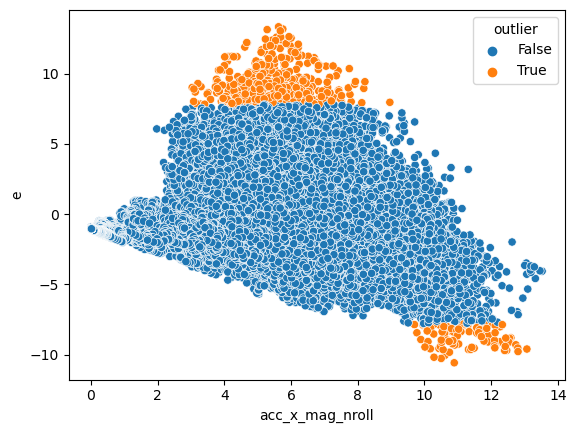

In [133]:
sns.scatterplot(data=df, x='acc_x_mag_nroll', y='e', hue='outlier')

<Axes: xlabel='acc_z_mag_nroll', ylabel='Count'>

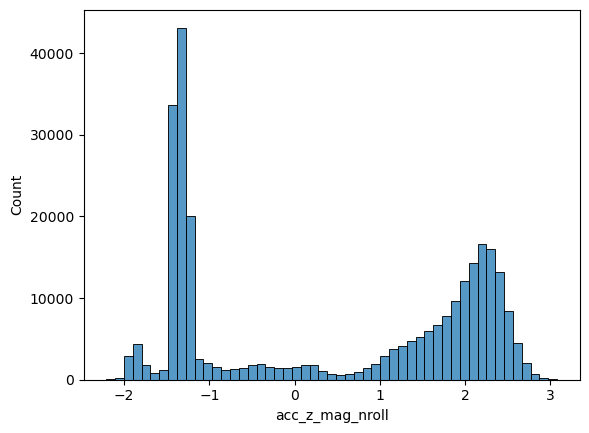

In [58]:
sns.histplot(np.log(df['acc_z_mag_nroll']))

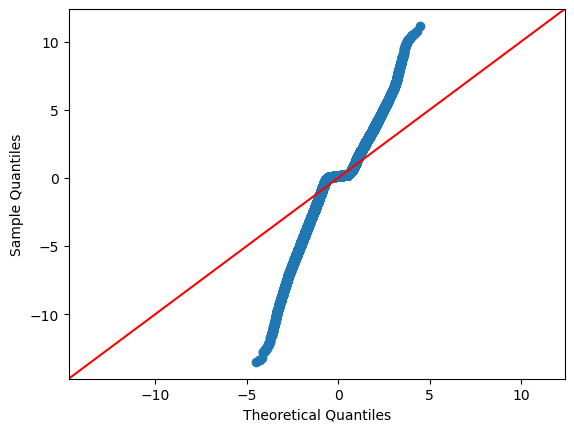

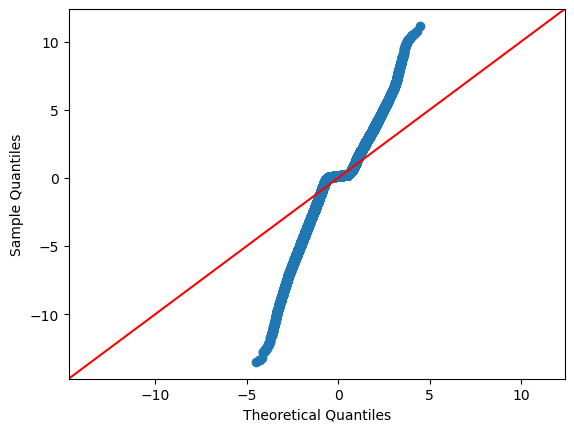

In [51]:
sm.qqplot(df['e'], line='45')

<Axes: xlabel='time', ylabel='acc_z_mag_nroll'>

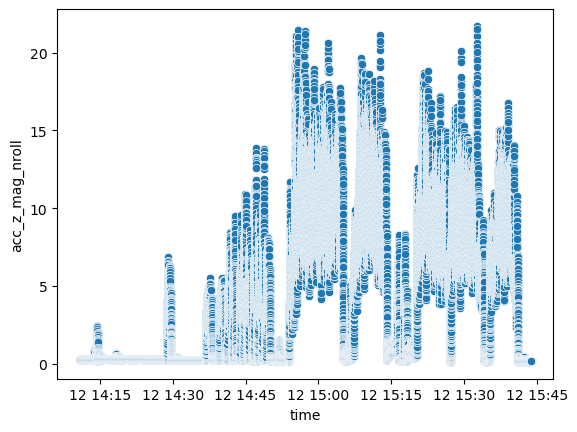

In [34]:
sns.scatterplot(data=df, x='time', y='acc_z_mag_nroll')

In [9]:
tests[i].head()

,class,device,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,...,roll,roll_st,yaw,yaw_st,heading,acc_len,mag_len,mag_st,acc_z_norm,acc_z_absn
0,ATT,LSM9DS1,2025-10-12 15:48:28.016241+00:00,2.904887,-1.572084,8.846265,-3.78,-3.01,-0.28,589.0,...,0.303267,N,49.575846,N,320.341484,9.442787,1326.268261,N,-0.963735,0.963735
1,ATT,LSM9DS1,2025-10-12 15:48:28.036307+00:00,2.251646,-1.710868,8.597412,-5.46,-3.08,-0.56,577.0,...,0.284371,N,49.659232,N,322.260946,9.050551,1331.630392,N,-1.212588,1.212588
2,ATT,LSM9DS1,2025-10-12 15:48:28.056471+00:00,2.907279,-1.148555,9.868000,-4.97,-3.43,17.71,596.0,...,0.224036,N,49.788052,N,320.942869,10.351275,1330.363296,N,0.058000,0.058000
3,ATT,LSM9DS1,2025-10-12 15:48:28.076608+00:00,1.986043,-1.663012,8.784052,-3.36,-3.43,-0.28,583.0,...,0.238550,N,49.926958,N,321.673331,9.158031,1308.741953,N,-1.025948,1.025948
4,ATT,LSM9DS1,2025-10-12 15:48:28.096691+00:00,2.273181,-1.201197,9.712467,-4.83,-3.99,-0.49,585.0,...,0.233073,N,49.817184,N,320.964487,10.047002,1316.893883,N,-0.097533,0.097533


In [17]:
df['acc_x'].describe()

count    240684.000000
mean          2.138674
std           4.997618
min         -45.710090
25%           0.406780
50%           2.203790
75%           2.749353
max          63.043697
Name: acc_x, dtype: float64

count    2829.000000
mean       -0.000320
std         1.993544
min        -7.338013
25%        -1.357871
50%        -0.046604
75%         1.304862
max         8.968594
Name: acc_x_nroll, dtype: float64

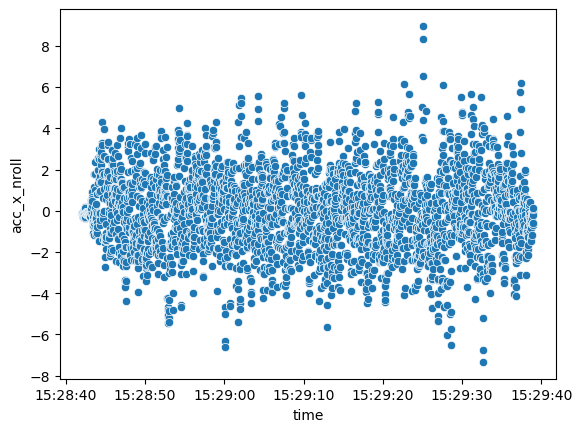

count    3822.000000
mean        0.000012
std         1.698218
min        -6.431577
25%        -1.079192
50%        -0.021684
75%         1.032833
max         5.966115
Name: acc_x_nroll, dtype: float64

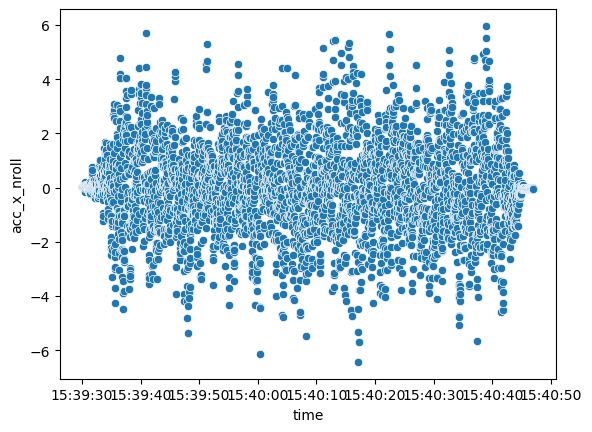

count    2083.000000
mean       -0.000301
std         2.284872
min        -7.127131
25%        -1.503759
50%         0.052773
75%         1.376243
max         8.176884
Name: acc_x_nroll, dtype: float64

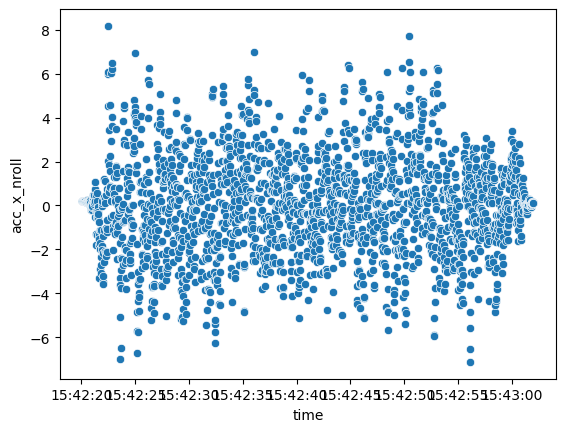

count    2980.000000
mean       -0.000072
std         2.150441
min        -6.165348
25%        -1.406502
50%         0.002392
75%         1.267836
max        10.382456
Name: acc_x_nroll, dtype: float64

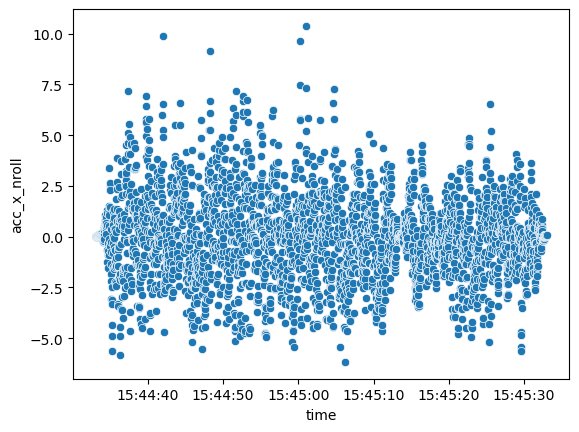

count    1985.000000
mean        0.000067
std         2.237502
min        -8.858549
25%        -1.398685
50%        -0.003670
75%         1.392303
max         8.610492
Name: acc_x_nroll, dtype: float64

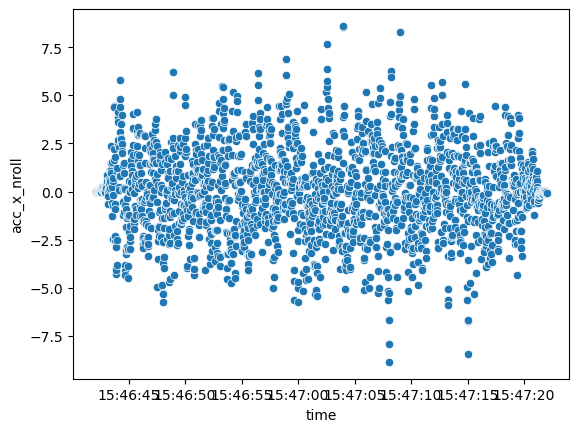

count    1835.000000
mean       -0.000302
std         2.238937
min        -6.621877
25%        -1.413181
50%        -0.066500
75%         1.262952
max        12.899248
Name: acc_x_nroll, dtype: float64

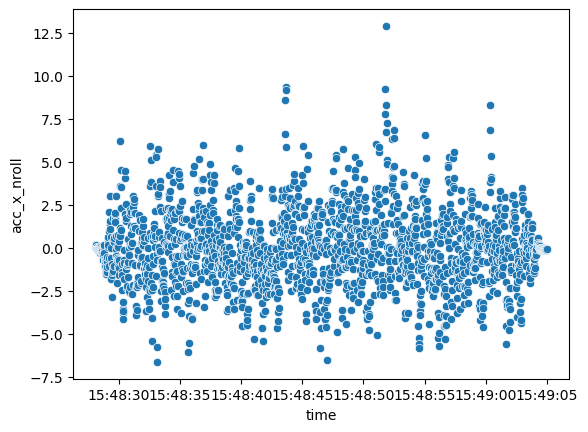

In [37]:
for i in range(len(tests)):
    display(tests[i]['acc_x_nroll'].describe())
    sns.scatterplot(data=tests[i], x='time', y='acc_x_nroll')
    plt.show()